# Drive Cycle Comparison: WLTP vs Nurburgring

This notebook compares standard road driving (WLTP) with high-performance track driving (Nurburgring) using PyBaMM simulation with the BYD Blade Prismatic 135Ah LFP cell.

## Overview
- **Cell**: BYD Blade Prismatic 135Ah LFP
- **Pack Configuration**: 120S3P (~100 kWh, 400V)
- **Drive Cycles**: 
  - **WLTP**: Worldwide Harmonized Light-Duty Test Procedure (23.3 km)
  - **Nurburgring**: Nordschleife track (20.8 km)
  
## Objectives
1. Simulate both drive cycles with identical battery configuration
2. Compare energy consumption, efficiency, and thermal behavior
3. Analyze range implications for different driving scenarios

## 1. Load Cell Parameters

Load the BYD Blade Prismatic 135Ah cell design from manifest.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from model_library.spmet_drive import run_spmet_drivecycle

In [2]:
# Load BYD Blade cell manifest
manifest_path = Path("../cells/VW_ID3_Pouch_80Ah_manifest.json")
# manifest_path = Path("../cells/BYD_Blade_Prismatic_135Ah_manifest.json")

material_path = Path("../materials")

with open(manifest_path, 'r') as f:
    cell_design_manifest = json.load(f)
    
    # Load material data for separator and electrolyte
    for component in ["separator", "electrolyte"]:
        print(f"Loading material data for {component}") 
        material_name = cell_design_manifest["cell_design"][component]["material"]["type"]
        material_file_path = material_path / f"{material_name}.json"
        with open(material_file_path, "r") as mf:
            material_data = json.load(mf)
            cell_design_manifest["cell_design"][component]["material"] = material_data

    # Load material data for electrodes
    for component in ["negative_electrode", "positive_electrode"]:
        print(f"Loading material data for {component}") 
        material_name = cell_design_manifest["cell_design"][component]["coating"]["formulation"]["primary_active_material"]["name"]
        material_file_path = material_path / f"{material_name}.json"
        with open(material_file_path, "r") as mf:
            material_data = json.load(mf)
            cell_design_manifest["cell_design"][component]["material"] = material_data

# Extract key parameters
nominal_capacity = cell_design_manifest['kpis']['nominal_capacity']['value']
nominal_energy = cell_design_manifest["kpis"]["nominal_energy"]["value"] 
cell_design = cell_design_manifest["cell_design"]
upper_voltage_cutoff = cell_design["upper_voltage_cutoff"]["value"]
lower_voltage_cutoff = cell_design["lower_voltage_cutoff"]["value"]

# Add required fields
cell_nominal_voltage = cell_design_manifest['kpis']['nominal_voltage']['value']
cell_design["nominal_capacity"] = {"value": nominal_capacity, "unit": "Ah"}
cell_design["nominal_energy"] = {"value": nominal_energy, "unit": "Wh"}
cell_design["cell_volume"] = {
    "value": cell_design_manifest['kpis']['cell_volume']['value'],
    "unit": "cm3"
}
cell_design["nominal_voltage"] = {
    "value": cell_nominal_voltage,
    "unit": "V"
}

print(f"\nCell loaded: {nominal_capacity} Ah, {nominal_energy} Wh")
print(f"Voltage range: {lower_voltage_cutoff} - {upper_voltage_cutoff} V")

Loading material data for separator
Loading material data for electrolyte
Loading material data for negative_electrode
Loading material data for positive_electrode

Cell loaded: 80.5 Ah, 295.435 Wh
Voltage range: 2.8 - 4.2 V


In [3]:
# Battery pack configuration (120S3P for ~100 kWh)
pack_config = {
    "pack_max_energy_kWh": 120,      # ~400V nominal (120 cells × 3.3V)
    "pack_nominal_voltage_V": 400,      # 3P for high current capability
    "rated_peak_power_kW": 250,
}
pack_config["pack_cells_in_series"] = int(pack_config["pack_nominal_voltage_V"] / cell_design["nominal_voltage"]["value"])
pack_config["pack_cells_in_parallel"] = int((pack_config["pack_max_energy_kWh"] * 1000) / (nominal_capacity * pack_config["pack_cells_in_series"]))
total_cells = pack_config["pack_cells_in_series"] * pack_config["pack_cells_in_parallel"]

print(f"Battery Pack Configuration:")
print(f"  Configuration: {pack_config['pack_cells_in_series']}S{pack_config['pack_cells_in_parallel']}P")
print(f"  Total cells: {total_cells}")
print(f"  Nominal voltage: {pack_config['pack_nominal_voltage_V']:.0f} V")
print(f"  Max power: {pack_config['rated_peak_power_kW']:.1f} kW")
print(f"  Energy: {pack_config['pack_max_energy_kWh']:.1f} kWh")

# Vehicle configuration for range estimation
# These parameters will be passed directly to spmet_drive.run_drive_cycle() for physics-based range calculation
vehicle_weight_kg = 2200                  # Vehicle curb weight including battery [kg]
vehicle_drag_coefficient = 0.28           # Aerodynamic drag coefficient Cd
vehicle_frontal_area_m2 = 2.35            # Frontal/reference area [m²]
vehicle_rolling_resistance = 0.01         # Rolling resistance coefficient
vehicle_drivetrain_efficiency = 0.90      # Drivetrain efficiency (motor to wheels)

print(f"\nVehicle Configuration:")
print(f"  Weight: {vehicle_weight_kg} kg")
print(f"  Drag coefficient (Cd): {vehicle_drag_coefficient}")
print(f"  Frontal area: {vehicle_frontal_area_m2} m²")
print(f"  Rolling resistance: {vehicle_rolling_resistance}")
print(f"  Drivetrain efficiency: {vehicle_drivetrain_efficiency*100:.0f}%")

Battery Pack Configuration:
  Configuration: 108S13P
  Total cells: 1404
  Nominal voltage: 400 V
  Max power: 250.0 kW
  Energy: 120.0 kWh

Vehicle Configuration:
  Weight: 2200 kg
  Drag coefficient (Cd): 0.28
  Frontal area: 2.35 m²
  Rolling resistance: 0.01
  Drivetrain efficiency: 90%


In [4]:
# Load drive cycle data
drive_cycle_files = {
    "WLTP": {
        "path": Path("../drive_cycles/Auto WLTP Power.csv"),
        "distance_km": 23.266,  # WLTP Class 3 distance
    },
    "Nurburgring": {
        "path": Path("../drive_cycles/Track Nurburgring Power.csv"),
        "distance_km": 20.8,  # Nurburgring Nordschleife length
    },
}

# Load all drive cycles
drive_cycles = {}
for name, info in drive_cycle_files.items():
    df = pd.read_csv(info["path"])
    drive_cycles[name] = {
        "data": df,
        "distance_km": info["distance_km"],
    }
    print(f"{name} Cycle:")
    print(f"  Data points: {len(df)}")
    print(f"  Duration: {df['time (s)'].max()} s ({df['time (s)'].max()/60:.1f} min)")
    print(f"  Power range: {df['power (W)'].min():.1f} to {df['power (W)'].max():.1f} W")
    print(f"  Distance: {info['distance_km']} km")
    print()

WLTP Cycle:
  Data points: 3601
  Duration: 3600 s (60.0 min)
  Power range: -80.9 to 0.0 W
  Distance: 23.266 km

Nurburgring Cycle:
  Data points: 420
  Duration: 419 s (7.0 min)
  Power range: -161.9 to 89.7 W
  Distance: 20.8 km



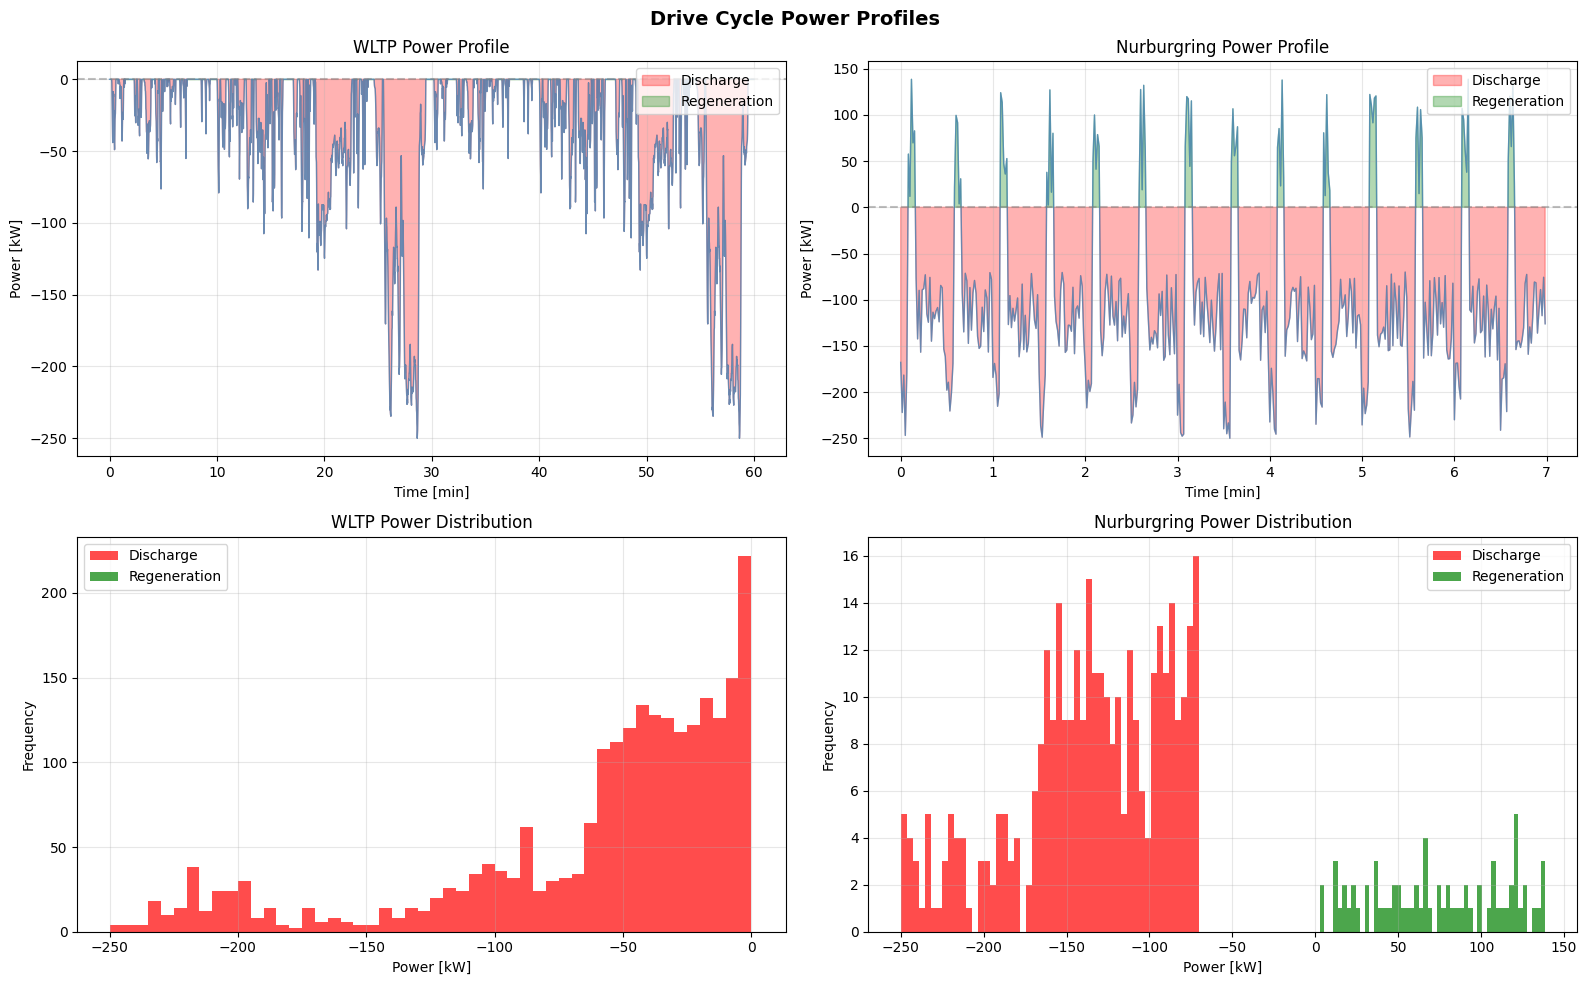

In [5]:
# Visualize all drive cycles
n_cycles = len(drive_cycles)
fig, axes = plt.subplots(2, n_cycles, figsize=(8*n_cycles, 10))
if n_cycles == 1:
    axes = axes.reshape(-1, 1)

colors = {'WLTP': 'steelblue', 'Nurburgring': 'steelblue'}

for col, (cycle_name, cycle_info) in enumerate(drive_cycles.items()):
    df = cycle_info["data"]
    time_min = df['time (s)'] / 60
    power_kW = df["power (W)"] / df["power (W)"].abs().max() * pack_config["rated_peak_power_kW"]
    color = colors.get(cycle_name, 'steelblue')
    
    # Power profile
    ax = axes[0, col]
    ax.fill_between(time_min, 0, power_kW, where=(power_kW < 0), 
                    color='red', alpha=0.3, label='Discharge', interpolate=True)
    ax.fill_between(time_min, 0, power_kW, where=(power_kW >= 0), 
                    color='green', alpha=0.3, label='Regeneration', interpolate=True)
    ax.plot(time_min, power_kW, linewidth=1, color=color, alpha=0.8)
    ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    ax.set_xlabel('Time [min]')
    ax.set_ylabel('Power [kW]')
    ax.set_title(f'{cycle_name} Power Profile')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)
    
    # Power histogram
    ax = axes[1, col]
    discharge = power_kW[power_kW < 0]
    regen = power_kW[power_kW > 0]
    ax.hist(discharge, bins=50, alpha=0.7, label='Discharge', color='red')
    ax.hist(regen, bins=50, alpha=0.7, label='Regeneration', color='green')
    ax.set_xlabel('Power [kW]')
    ax.set_ylabel('Frequency')
    ax.set_title(f'{cycle_name} Power Distribution')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Drive Cycle Power Profiles', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [6]:
# Run simulations for all drive cycles
pack_nominal_voltage = pack_config["pack_nominal_voltage_V"]
pack_peak_power_kW = pack_config["rated_peak_power_kW"]
pack_max_energy_kWh = pack_config["pack_max_energy_kWh"]

print(f"Pack Specifications:")
print(f"  Nominal voltage: {pack_nominal_voltage:.1f} V")
print(f"  Peak power: {pack_peak_power_kW:.1f} kW")
print(f"  Energy: {pack_max_energy_kWh:.1f} kWh\n")

# Cycles to compare
cycles_to_compare = ["WLTP", "Nurburgring"]

# Store results
comparison_results = {}

for cycle_name in cycles_to_compare:
    print(f"\n{'='*60}")
    print(f"Running {cycle_name}...")
    print(f"{'='*60}")
    
    # Get cycle data
    cycle_info = drive_cycles[cycle_name]
    df = cycle_info["data"]
    
    # Process power data: normalize by abs max, scale to pack rated peak power
    time_s = df['time (s)'].values
    power_raw = df['power (W)'].values
    power_abs_max = np.abs(power_raw).max()
    power_normalized = power_raw / power_abs_max
    pack_power_W = -power_normalized * pack_peak_power_kW * 1000  # Negate for PyBaMM convention
    
    print(f"Power Processing:")
    print(f"  Raw power range: {power_raw.min():.1f} to {power_raw.max():.1f} W")
    print(f"  Abs max: {power_abs_max:.1f} W")
    print(f"  Pack power range: {pack_power_W.min()/1000:.1f} to {pack_power_W.max()/1000:.1f} kW")
    
    # Build drive cycle dict
    drive_cycle = {
        "time_s": time_s,
        "power_W": pack_power_W,
        "label": cycle_name,
        "distance_km": cycle_info["distance_km"],
    }
    
    # Build simulation config
    config = {
        "ambient_temperature_K": 298.15,
        "initial_temperature_K": 298.15,
        "contact_resistance_Ohm": 1e-5,
        "total_heat_transfer_coefficient_W_m2K": 0.1,
        "cooling_surface_area_m2": 3.0,
        "initial_soc": 0.95,
        "upper_voltage_cutoff_V": upper_voltage_cutoff,
        "lower_voltage_cutoff_V": lower_voltage_cutoff,
        "period": "1 second",
        "drive_cycle": drive_cycle,
        "pack_max_energy_kWh": pack_max_energy_kWh,
        "pack_nominal_voltage_V": pack_nominal_voltage,
        "pack_rated_peak_power_kW": pack_peak_power_kW,
        "min_soc": 0.10,
        "max_soc": 0.95,
        "vehicle_weight_kg": vehicle_weight_kg,
        "vehicle_drag_coefficient": vehicle_drag_coefficient,
        "vehicle_frontal_area_m2": vehicle_frontal_area_m2,
        "vehicle_rolling_resistance": vehicle_rolling_resistance,
        "vehicle_drivetrain_efficiency": vehicle_drivetrain_efficiency,
    }
    
    # Run simulation
    result = run_spmet_drivecycle(cell_design=cell_design, simulation_config=config)
    comparison_results[cycle_name] = result
    
    if result['success']:
        print(f"\n  Completed: {len(result['timeseries']['time_s'])} data points")
        print(f"  SOC change: {result['energy_analysis']['soc_change_pct']:.1f}%")
        print(f"  Temp rise: {result['summary']['temperature_rise_C']:.1f}°C")
    else:
        print(f"  Failed: {result.get('error', 'Unknown')}")

Pack Specifications:
  Nominal voltage: 400.0 V
  Peak power: 250.0 kW
  Energy: 120.0 kWh


Running WLTP...
Power Processing:
  Raw power range: -80.9 to 0.0 W
  Abs max: 80.9 W
  Pack power range: -0.0 to 250.0 kW

  Pack config: 109S4P (406 cells)
  Pack power range: -0.0 to 250000.0 W
  Cell power range: -0.0 to 615.5 W

Building model parameters from manifest...

RUNNING DRIVE CYCLE
  Type: Power
  Power range: -0.0 to 615.5 W
  Label: WLTP
  Duration: 3600.0 s (60.0 min)
  Data points: 3601
  Custom terminations: 2
  Running simulation (initial SOC: 95%)...
  Completed: 3601 data points

  Completed: 3601 data points
  SOC change: 32.3%
  Temp rise: 7.5°C

Running Nurburgring...
Power Processing:
  Raw power range: -161.9 to 89.7 W
  Abs max: 161.9 W
  Pack power range: -138.6 to 250.0 kW

  Pack config: 109S4P (406 cells)
  Pack power range: -138584.9 to 250000.0 W
  Cell power range: -341.2 to 615.5 W

Building model parameters from manifest...

RUNNING DRIVE CYCLE
  Type: Powe

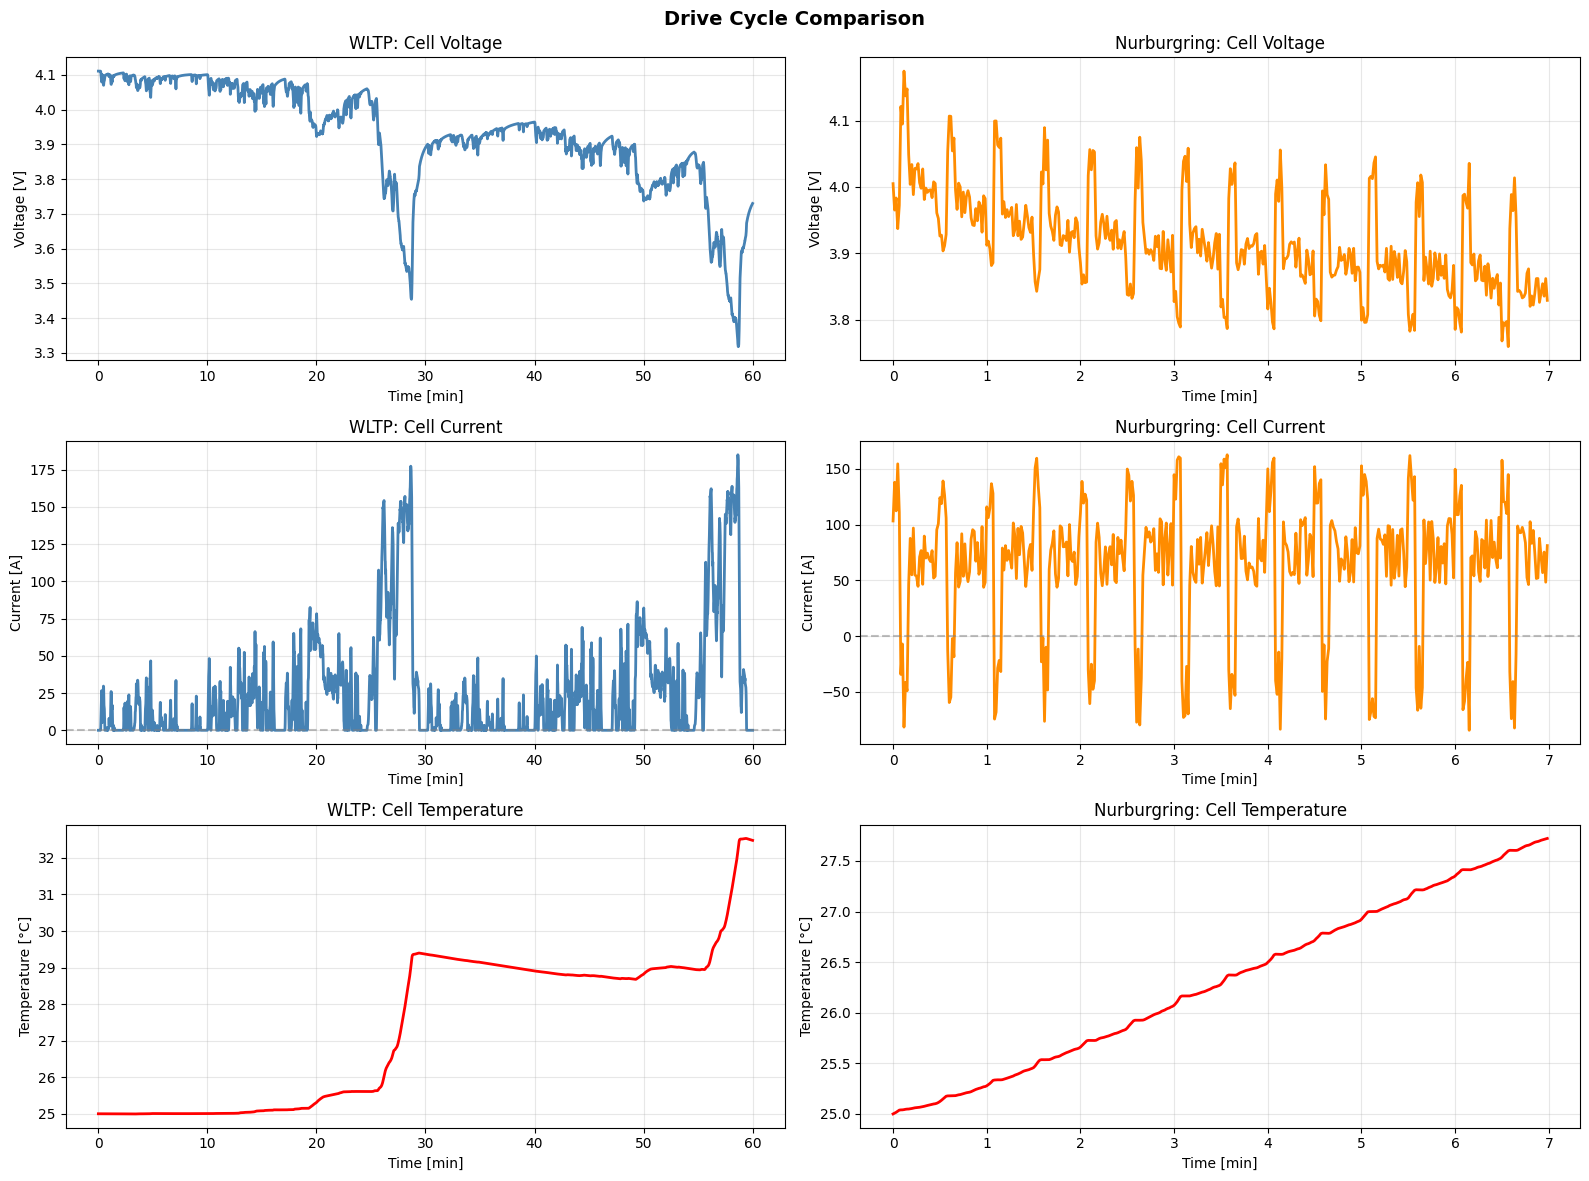

In [7]:
# Side-by-side visualization for all cycles
successful_cycles = [name for name, r in comparison_results.items() if r['success']]
n_cycles = len(successful_cycles)

if n_cycles > 0:
    fig, axes = plt.subplots(3, n_cycles, figsize=(8*n_cycles, 12))
    if n_cycles == 1:
        axes = axes.reshape(-1, 1)
    
    colors = {'WLTP': 'steelblue', 'Nurburgring': 'darkorange'}
    
    for col, cycle_name in enumerate(successful_cycles):
        ts = comparison_results[cycle_name]['timeseries']
        time_min = np.array(ts['time_s']) / 60
        color = colors.get(cycle_name, 'steelblue')
        
        # Voltage
        ax = axes[0, col]
        ax.plot(time_min, ts['voltage_V'], linewidth=2, color=color)
        ax.set_xlabel('Time [min]')
        ax.set_ylabel('Voltage [V]')
        ax.set_title(f'{cycle_name}: Cell Voltage')
        ax.grid(True, alpha=0.3)
        
        # Current
        ax = axes[1, col]
        ax.plot(time_min, ts['current_A'], linewidth=2, color=color)
        ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
        ax.set_xlabel('Time [min]')
        ax.set_ylabel('Current [A]')
        ax.set_title(f'{cycle_name}: Cell Current')
        ax.grid(True, alpha=0.3)
        
        # Temperature
        ax = axes[2, col]
        temp_C = np.array(ts['temperature_K']) - 273.15
        ax.plot(time_min, temp_C, linewidth=2, color='red')
        ax.set_xlabel('Time [min]')
        ax.set_ylabel('Temperature [°C]')
        ax.set_title(f'{cycle_name}: Cell Temperature')
        ax.grid(True, alpha=0.3)
    
    plt.suptitle('Drive Cycle Comparison', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [8]:
# Build comparison table from all successful cycles
successful_cycles = [name for name, r in comparison_results.items() if r['success']]

if len(successful_cycles) >= 2:
    # Build comparison DataFrame dynamically
    metrics = [
        'Duration [min]',
        'Distance [km]',
        'Net Energy [Wh]',
        'Energy per km [Wh/km]',
        'Peak Current [A]',
        'Peak C-rate',
        'Temperature Rise [°C]',
        'Regeneration [%]',
        'Cycles Possible',
        'Total Range [km]'
    ]
    
    comparison_data = {'Metric': metrics}
    
    for cycle_name in successful_cycles:
        result = comparison_results[cycle_name]
        summary = result['summary']
        energy = result['energy_analysis']
        range_info = result['range_analysis']
        
        comparison_data[cycle_name] = [
            f"{summary['duration_min']:.1f}",
            f"{range_info['cycle_distance_km']:.1f}",
            f"{energy['energy_net_Wh']:.1f}",
            f"{range_info.get('energy_per_km_Wh', 0):.2f}",
            f"{summary['current_max_A']:.1f}",
            f"{summary['current_max_A']/nominal_capacity:.2f}",
            f"{summary['temperature_rise_C']:.2f}",
            f"{energy['regeneration_ratio_pct']:.1f}",
            f"{range_info['cycles_possible']:.1f}",
            f"{range_info.get('range_km', 0):.1f}"
        ]
    
    comparison = pd.DataFrame(comparison_data)
    
    print("\n" + "="*80)
    print("DRIVE CYCLE COMPARISON")
    print("="*80)
    print(comparison.to_string(index=False))
    
    # Key insights (comparing first two cycles)
    if len(successful_cycles) >= 2:
        c1, c2 = successful_cycles[0], successful_cycles[1]
        r1, r2 = comparison_results[c1], comparison_results[c2]
        
        print("\n" + "="*80)
        print("KEY INSIGHTS")
        print("="*80)
        
        e1 = r1['range_analysis'].get('energy_per_km_Wh', 0)
        e2 = r2['range_analysis'].get('energy_per_km_Wh', 0)
        if e1 > 0:
            energy_diff_pct = (e2 / e1 - 1) * 100
            print(f"\n1. Energy Consumption:")
            print(f"   {c2} uses {energy_diff_pct:+.1f}% energy per km vs {c1}")
        
        range1 = r1['range_analysis'].get('range_km', 0)
        range2 = r2['range_analysis'].get('range_km', 0)
        if range2 > 0:
            range_ratio = range1 / range2
            print(f"\n2. Range Impact:")
            print(f"   {c1} range is {range_ratio:.1f}x the {c2} range")
        
        print(f"\n3. Thermal Load:")
        print(f"   {c1}: {r1['summary']['temperature_rise_C']:.2f}°C rise")
        print(f"   {c2}: {r2['summary']['temperature_rise_C']:.2f}°C rise")
        
        print(f"\n4. Power Demand:")
        print(f"   {c1} peak: {r1['summary']['current_max_A']:.1f}A ({r1['summary']['current_max_A']/nominal_capacity:.1f}C)")
        print(f"   {c2} peak: {r2['summary']['current_max_A']:.1f}A ({r2['summary']['current_max_A']/nominal_capacity:.1f}C)")
        
        # Pack-level comparison
        print(f"\n5. Pack-Level Performance ({total_cells}-cell pack, {pack_max_energy_kWh:.1f} kWh):")
        for cycle_name in successful_cycles:
            pack_energy_kWh = comparison_results[cycle_name]['energy_analysis']['energy_net_Wh'] * total_cells / 1000
            print(f"   {cycle_name}: {pack_energy_kWh:.2f} kWh ({pack_energy_kWh/pack_max_energy_kWh*100:.1f}% of pack)")


DRIVE CYCLE COMPARISON
               Metric  WLTP Nurburgring
       Duration [min]  60.0         7.0
        Distance [km]  23.3        20.8
      Net Energy [Wh]  97.6        28.9
Energy per km [Wh/km]  4.19        1.39
     Peak Current [A] 185.1       162.6
          Peak C-rate  2.30        2.02
Temperature Rise [°C]  7.53        2.72
     Regeneration [%]   0.0         9.1
      Cycles Possible   2.6         9.2
     Total Range [km]  61.3       190.6

KEY INSIGHTS

1. Energy Consumption:
   Nurburgring uses -66.9% energy per km vs WLTP

2. Range Impact:
   WLTP range is 0.3x the Nurburgring range

3. Thermal Load:
   WLTP: 7.53°C rise
   Nurburgring: 2.72°C rise

4. Power Demand:
   WLTP peak: 185.1A (2.3C)
   Nurburgring peak: 162.6A (2.0C)

5. Pack-Level Performance (1404-cell pack, 120.0 kWh):
   WLTP: 137.00 kWh (114.2% of pack)
   Nurburgring: 40.57 kWh (33.8% of pack)


In [9]:
# Export results for all cycles
for cycle_name, result in comparison_results.items():
    if result['success']:
        # Export timeseries
        ts_df = pd.DataFrame(result['timeseries'])
        filename = f'{cycle_name.lower()}_timeseries.csv'
        ts_df.to_csv(filename, index=False)
        print(f"{cycle_name} timeseries exported to: {filename}")

# Export comparison summary
summary_data = []
for cycle_name, result in comparison_results.items():
    if result['success']:
        summary_data.append({
            'cycle': cycle_name,
            **result['summary'],
            **result['energy_analysis'],
            **{k: v for k, v in result['range_analysis'].items() if not isinstance(v, dict)},
        })

if summary_data:
    summary_df = pd.DataFrame(summary_data)
    summary_df.to_csv('drive_cycle_comparison.csv', index=False)
    print("\nComparison summary exported to: drive_cycle_comparison.csv")

WLTP timeseries exported to: wltp_timeseries.csv
Nurburgring timeseries exported to: nurburgring_timeseries.csv

Comparison summary exported to: drive_cycle_comparison.csv
